# Logistic Regression Build from Scratch.

---

In [1]:
import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
data = pd.read_csv("employee_attrition_preprocessed.csv")

## Train-Test-Split:

In [3]:
X = data.drop(columns=['Attrition', 'Unnamed: 0'])
y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Building Model:

In [5]:
# Batch Gradient Descent:

class GDLogisticRegression:

    def __init__(self, learning_rate=0.01, max_iter=100):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.intercept = None
        self.coef = None
        self.loss = []

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.X_train = np.insert(self.X_train, 0, 1, axis=1)
        weights = np.zeros(self.X_train.shape[1])

        # When dataset is imbalance we use class_weights='balanced'
        n_classes, class_samples = np.unique(self.y_train, return_counts=True)
        class_weights = self.X_train.shape[0] / (len(n_classes) + class_samples)

        sample_weights = np.where(self.y_train == 0, class_weights[0], class_weights[1])
        
        for j in range(self.max_iter):
            y_pred = self.sigmoid(np.dot(self.X_train, weights))
            
            slope = -(np.dot((self.y_train - y_pred) * sample_weights, self.X_train) / self.X_train.shape[0])
            weights = weights - (self.learning_rate * slope)

            loss = -np.mean(sample_weights * (self.y_train * np.log(y_pred)) + ((1 - self.y_train) * np.log(1 - y_pred)))
            self.loss.append(loss)

        self.intercept = weights[0]
        self.coef = weights[1:]

    def predict_proba(self, X_test):
        
        z = np.dot(X_test, self.coef) + self.intercept
        return self.sigmoid(z)
    
    def predict(self, X_test, threshold):
        
        return (self.predict_proba(X_test) >= threshold).astype(int)

In [6]:
gdlr = GDLogisticRegression(learning_rate=0.01, max_iter=1000)

start_time = time.time()
gdlr.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Successfully!")
print(f"Time Taken for Training: {end_time:.2f}s")

Model Trained Successfully!
Time Taken for Training: 1.12s


## Results:

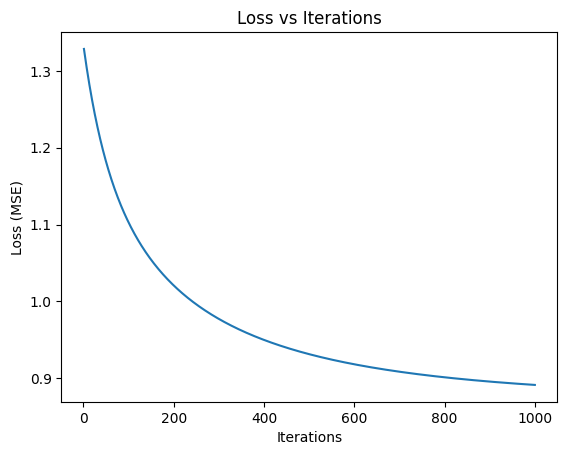

In [7]:
plt.plot(range(1, len(gdlr.loss) + 1), gdlr.loss)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.show()

In [8]:
y_pred = gdlr.predict(X_test, threshold=0.5)

print(f"Accuracy: {(accuracy_score(y_test, y_pred)*100):.2f}%")

print(f"\nPrecision: {(precision_score(y_test, y_pred)*100):.2f}%")

print(f"\nRecall: {(recall_score(y_test, y_pred)*100):.2f}%")

print(f"\nF1 Score: {(f1_score(y_test, y_pred)*100):.2f}")

print("\n")
matrix = confusion_matrix(y_test, y_pred)
matrix_df = pd.DataFrame(matrix, index=['Actual Stay', 'Actual Leave'], columns=['Predicted Stay', 'Predicted Leave'])
matrix_df

Accuracy: 73.36%

Precision: 12.36%

Recall: 78.57%

F1 Score: 21.36




,Predicted Stay,Predicted Leave
Actual Stay,212,78
Actual Leave,3,11
